## Proyek Analisis Sentimen Ulasan Aplikasi Google Classroom: Pendekatan NLP terhadap Data dari Amerika Serikat

### Import Library dan Konfigurasi

In [33]:
# --- Standard Library ---
import re
import string
import datetime as dt

# --- Third-Party Imports ---
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from wordcloud import WordCloud
from imblearn.over_sampling import SMOTE

# --- NLTK Resources ---
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# --- Configuration ---
pd.options.mode.chained_assignment = None  # Suppress chaining warnings
SEED = 42
np.random.seed(SEED)

# --- Constants ---
# URL untuk Lexicon (Kamus Kata)
POSITIVE_URL = 'https://raw.githubusercontent.com/jeffreybreen/twitter-sentiment-analysis-tutorial-201107/master/data/opinion-lexicon-English/positive-words.txt'
NEGATIVE_URL = 'https://raw.githubusercontent.com/jeffreybreen/twitter-sentiment-analysis-tutorial-201107/master/data/opinion-lexicon-English/negative-words.txt'

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Dictionary untuk normalisasi slang words bahasa Inggris (US)
slangwords = {
    # Common contractions and abbreviations
    "u": "you", "ur": "your", "r": "are", "n": "and", "w/": "with", "w/o": "without",
    "bc": "because", "b4": "before", "2day": "today", "2morrow": "tomorrow", "2nite": "tonight",
    "4": "for", "2": "to", "4ever": "forever", "2gether": "together",

    # Internet slang and texting
    "lol": "laugh out loud", "omg": "oh my god", "wtf": "what the f", "btw": "by the way",
    "imo": "in my opinion", "imho": "in my humble opinion", "tbh": "to be honest",
    "ngl": "not gonna lie", "smh": "shaking my head", "fyi": "for your information",
    "asap": "as soon as possible", "aka": "also known as", "irl": "in real life",

    # Informal expressions
    "gonna": "going to", "wanna": "want to", "gotta": "got to", "kinda": "kind of",
    "sorta": "sort of", "dunno": "do not know", "lemme": "let me", "gimme": "give me",
    "shoulda": "should have", "coulda": "could have", "woulda": "would have",

    # Common misspellings and shortcuts
    "thx": "thanks", "thnx": "thanks", "plz": "please", "pls": "please",
    "msg": "message", "pic": "picture", "vid": "video", "app": "application",
    "def": "definitely", "prob": "probably", "obv": "obviously", "srsly": "seriously",

    # Positive slang
    "awesome": "amazing", "cool": "good", "lit": "exciting", "dope": "good",
    "sick": "amazing", "fire": "excellent", "bomb": "amazing", "tight": "cool",

    # Negative slang
    "sucks": "bad", "trash": "terrible", "lame": "boring", "wack": "bad",
    "weak": "poor", "awful": "terrible", "crap": "bad", "crappy": "bad",

    # Intensifiers
    "so": "very", "super": "very", "hella": "very", "mad": "very",
    "crazy": "very", "insane": "extremely", "sick": "very", "wild": "very",

    # Common replacements
    "yeah": "yes", "yep": "yes", "yup": "yes", "nah": "no", "nope": "no",
    "ok": "okay", "k": "okay", "aight": "alright", "sup": "what is up",
    "bout": "about", "tryna": "trying to", "finna": "going to",

    # Social media specific
    "dm": "direct message", "pm": "private message", "rt": "retweet",
    "fb": "facebook", "ig": "instagram", "yt": "youtube", "tiktok": "tik tok",

    # Time and frequency
    "rn": "right now", "atm": "at the moment", "24/7": "twenty four seven",
    "bout": "about", "round": "around", "thru": "through", "til": "until",

    # Emotions and reactions
    "meh": "okay", "ugh": "frustrated", "eww": "disgusting", "yay": "hooray",
    "woah": "wow", "whoa": "wow", "geez": "gosh", "dang": "damn",

    # Common typos and variations
    "sooo": "so", "soooo": "so", "nooo": "no", "yesss": "yes",
    "omggg": "oh my god", "heyyyy": "hey", "byeee": "bye"
}

### Eksploratory Data Analysis

In [4]:
app_reviews_df = pd.read_csv('ulasan_aplikasi.csv')

In [5]:
jumlah_ulasan, jumlah_ulasan = app_reviews_df.shape

In [6]:
app_reviews_df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,b92931a4-11b2-4ce0-9b10-e514107392b8,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,My experience with this app is not the greates...,3.0,75.0,3.27.727990346,2025-03-15 17:09:27,"Hi, Theja. Thank you for taking the time to pr...",2025-03-15 18:03:36,3.27.727990346
1,eb5ce7e4-65c3-43cf-8dec-b2c5852fc255,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Google Classroom has been an invaluable tool f...,5.0,360.0,3.29.737819600,2025-04-10 13:13:45,NaN,NaN,3.29.737819600
2,259c8481-bc50-4d74-85de-5baaca0ab295,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"I've uninstalled, and reinstalled, and updated...",1.0,356.0,NaN,2020-08-31 21:26:29,NaN,NaN,NaN
3,73ad29f9-4065-4e74-93c9-0f27850279c4,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Worked fine for the first week I needed it, bu...",2.0,560.0,3.14.606759574,2024-02-23 00:23:22,NaN,NaN,3.14.606759574
4,bdfc3cc4-948a-44cd-aba4-5884180f4a4b,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,There is constant crashing and I cant do the w...,1.0,736.0,6.12.501.02.40,2021-01-10 20:23:09,NaN,NaN,6.12.501.02.40
...,...,...,...,...,...,...,...,...,...,...,...
28858,12bbb792-e32c-45c5-9c76-04fd5b76c70f,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Easy to do your school work on your phone,5.0,1.0,8.0.421.20.90.2,2022-11-13 09:03:44,NaN,NaN,8.0.421.20.90.2
28859,b2d090b6-e9ea-44fa-9778-4213b90b84cc,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Very fun learning for my kids tank u Google Cl...,5.0,0.0,6.8.341.03.30,2020-09-16 08:58:46,NaN,NaN,6.8.341.03.30
28860,aa6ba24b-9e05-46a0-8c47-df28100fbbcd,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,It doesn't download for offline reading,1.0,0.0,8.0.421.20.90.2,2023-03-08 10:25:33,"Hi, Olasiman. Can you try to uninstall and rei...",2023-03-08 12:53:33,8.0.421.20.90.2
28861,d0102986-bc1e-4b2b-9091-362cfa748cab,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,This is very good for school. I'm glad there i...,5.0,0.0,NaN,2020-08-19 04:41:51,NaN,NaN,NaN


In [7]:
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28863 entries, 0 to 28862
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   reviewId              28863 non-null  object 
 1   userName              28863 non-null  object 
 2   userImage             28863 non-null  object 
 3   content               28862 non-null  object 
 4   score                 28862 non-null  float64
 5   thumbsUpCount         28862 non-null  float64
 6   reviewCreatedVersion  22623 non-null  object 
 7   at                    28862 non-null  object 
 8   replyContent          6972 non-null   object 
 9   repliedAt             6972 non-null   object 
 10  appVersion            22623 non-null  object 
dtypes: float64(2), object(9)
memory usage: 2.4+ MB


In [8]:
app_reviews_df.isnull().sum()

,0
reviewId,0
userName,0
userImage,0
content,1
score,1
thumbsUpCount,1
reviewCreatedVersion,6240
at,1
replyContent,21891
repliedAt,21891


In [9]:
app_reviews_df = app_reviews_df.dropna()

In [10]:
app_reviews_df.duplicated().sum()

np.int64(0)

In [11]:
jumlah_ulasan, jumlah_ulasan = app_reviews_df.shape

In [12]:
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5555 entries, 0 to 28860
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   reviewId              5555 non-null   object 
 1   userName              5555 non-null   object 
 2   userImage             5555 non-null   object 
 3   content               5555 non-null   object 
 4   score                 5555 non-null   float64
 5   thumbsUpCount         5555 non-null   float64
 6   reviewCreatedVersion  5555 non-null   object 
 7   at                    5555 non-null   object 
 8   replyContent          5555 non-null   object 
 9   repliedAt             5555 non-null   object 
 10  appVersion            5555 non-null   object 
dtypes: float64(2), object(9)
memory usage: 520.8+ KB


In [13]:
app_reviews_df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,b92931a4-11b2-4ce0-9b10-e514107392b8,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,My experience with this app is not the greates...,3.0,75.0,3.27.727990346,2025-03-15 17:09:27,"Hi, Theja. Thank you for taking the time to pr...",2025-03-15 18:03:36,3.27.727990346
5,3cad6dec-1b4e-4da9-89b2-2bc6b3d33d0d,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"It won't let me into my account, and every tim...",1.0,314.0,3.16.626390407,2024-06-01 18:46:13,"Hi, Avian. If you have trouble signing in, you...",2024-06-01 20:21:44,3.16.626390407
6,682e625c-7329-4fd5-8794-3a3d4cfafa3b,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"One of the worst educational apps ever, gettin...",1.0,480.0,3.9.588547887,2024-01-15 09:12:05,"Hi, Ryan. Try restarting your phone and make s...",2024-01-15 10:04:27,3.9.588547887
14,ffe29369-f676-4829-9471-bc163a507256,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"This app allows me to access my classrooms, an...",3.0,245.0,3.13.597877957,2024-02-16 18:14:46,"Hi, Amelia. Try clearing the app’s cache and s...",2024-02-16 18:59:33,3.13.597877957
18,ac844341-c940-475e-853d-ad9502a90aec,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Been using this for a while just dealing with ...,1.0,801.0,9.0.261.20.90.6,2023-09-27 23:23:39,"Hi there. If you have trouble signing in, you ...",2023-09-28 01:09:09,9.0.261.20.90.6
...,...,...,...,...,...,...,...,...,...,...,...
28829,f70eecfc-4d9f-40e0-991e-97567a66b001,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,This app was ver useful for students for onlin...,1.0,2.0,7.3.141.04.34,2021-11-05 12:51:11,"Hi, Adarsh. Thanks for the review! We would lo...",2021-11-05 13:08:18,7.3.141.04.34
28837,1a0f5111-5021-4a57-bbee-9c38ba44ebc2,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,I have one problem when I upload my work it is...,1.0,0.0,7.6.301.21.33.07,2021-08-13 09:40:39,"Hi, Kartik. Attaching files from Drive on your...",2021-08-13 15:35:47,7.6.301.21.33.07
28844,790e48aa-9f1a-46d6-bc62-24a30ef48fbb,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Good app for online classes,3.0,0.0,7.5.221.03.44,2021-09-17 03:04:36,"Hi, Rajib. Thank you for taking the time to se...",2021-09-17 14:52:38,7.5.221.03.44
28851,71251e38-e262-4bfe-ab12-6da88a92af5f,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Waste. Slow and hanging my phone. No use simpl...,1.0,0.0,6.11.461.03.44,2021-06-29 13:01:52,Hi there. Please check your internet connectio...,2021-06-29 20:19:36,6.11.461.03.44


### Preprocessing Text

In [14]:
def clean_text(text):
    """Membersihkan teks dari karakter, angka, dan simbol yang tidak perlu."""

    text = re.sub(r'@[A-Za-z0-9]+', '', text)       # Hapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text)       # Hapus hashtag
    text = re.sub(r'RT[\s]', '', text)              # Hapus RT
    text = re.sub(r"http\S+", '', text)             # Hapus link
    text = re.sub(r'[0-9]+', '', text)              # Hapus angka
    text = re.sub(r'[^\w\s]', '', text)             # Hapus simbol aneh
    text = text.replace('\n', ' ')                  # Ganti baris baru
    text = text.translate(str.maketrans('', '', string.punctuation)) # Hapus tanda baca
    return text.strip().lower()

In [15]:
def casefoldingText(text):
  """Mengubah semua karakter dalam teks menjadi huruf kecil"""

  text = text.lower()
  return text

In [16]:
def tokenizingText(text):
  """Memecah atau membagi string, teks menjadi daftar token"""

  text = word_tokenize(text)
  return text

In [17]:
def filteringText(text):
    """
    Menghapus stopwords bahasa Inggris (US)
    """

    listStopwords = set(stopwords.words('english'))
    if not isinstance(text, list):
        return []
    filtered_words = [word for word in text if word not in listStopwords]
    return filtered_words

In [18]:
def stemmingText(text):
    """
    Melakukan stemming (akar kata) menggunakan PorterStemmer.
    """

    stemmer = PorterStemmer()
    words = word_tokenize(text)
    stemmed_words = [stemmer.stem(word) for word in words if word.isalpha()]
    stemmed_text = ' '.join(stemmed_words)
    return stemmed_text

In [19]:
def toSentence(list_words):
  """
  Mengubah daftar kata dalam kalimat
  """
  sentence = ' '.join(word for word in list_words)
  return sentence

In [20]:
def fix_slangwords(text):
    """
    Normalisasi slang words dalam teks bahasa Inggris
    """
    words = text.split()
    fixed_words = []

    for word in words:
        clean_word = word.lower().strip('.,!?;:"()[]{}')

        if clean_word in slangwords:
            punctuation = ''.join(c for c in word if not c.isalnum())
            if punctuation:
                normalized = slangwords[clean_word] + punctuation
            else:
                normalized = slangwords[clean_word]
            fixed_words.append(normalized)
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text


#### Pipeline Preprocessing

In [21]:
# 1. Cleaning
app_reviews_df['text_clean'] = app_reviews_df['content'].apply(clean_text)

# 2. Case Folding
app_reviews_df['text_casefolding'] = app_reviews_df['text_clean'].apply(casefoldingText)

# 3. Slang Normalization
app_reviews_df['text_slang'] = app_reviews_df['text_casefolding'].apply(fix_slangwords)

# 4. Tokenizing
app_reviews_df['text_tokens'] = app_reviews_df['text_slang'].apply(tokenizingText)

# 5. Stopword Removal
app_reviews_df['text_stopwords'] = app_reviews_df['text_tokens'].apply(filteringText)

# 6. Rejoin to Sentence (Text Akhir)
app_reviews_df['text_akhir'] = app_reviews_df['text_stopwords'].apply(toSentence)

display(app_reviews_df[['content', 'text_akhir']].head())

,content,text_akhir
0,My experience with this app is not the greates...,experience application greatest see required u...
5,"It won't let me into my account, and every tim...",wont let account every time try log account ta...
6,"One of the worst educational apps ever, gettin...",one worst educational apps ever getting worse ...
14,"This app allows me to access my classrooms, an...",application allows access classrooms appreciat...
18,Been using this for a while just dealing with ...,using dealing bugs come recently couldnt acces...


### Analisis Sentimen  (Lexison Based)

In [22]:
def load_lexicon(url, sentiment_score):
    """Fungsi helper untuk memuat lexicon dari URL."""
    lexicon = {}
    try:
        response = requests.get(url)
        if response.status_code == 200:
            lines = response.text.strip().split('\n')
            for line in lines:
                line = line.strip()
                if line and not line.startswith(';'):
                    lexicon[line] = sentiment_score
        else:
            print(f"Gagal mengambil data dari {url}")
    except Exception as e:
        print(f"Error memuat lexicon: {e}")
    return lexicon


In [23]:
# Memuat kamus kata
lexicon_positive = load_lexicon(POSITIVE_URL, 1)
lexicon_negative = load_lexicon(NEGATIVE_URL, -1)

print(f"Loaded {len(lexicon_positive)} positive words")
print(f"Loaded {len(lexicon_negative)} negative words")

Loaded 2006 positive words
Loaded 4783 negative words


In [24]:
def analyze_sentiment(text_list):
    """
    Menganalisis sentimen berdasarkan daftar kata.
    Returns: (score, polarity, positive_count, negative_count)
    """

    score = 0
    positive_count = 0
    negative_count = 0

    for word in text_list:
        if word in lexicon_positive:
            score += lexicon_positive[word]
            positive_count += 1
        elif word in lexicon_negative:
            score += lexicon_negative[word]
            negative_count += 1

    if score > 0:
        polarity = 'positive'
    elif score < 0:
        polarity = 'negative'
    else:
        polarity = 'neutral'

    return score, polarity, positive_count, negative_count

In [25]:
results = app_reviews_df['text_stopwords'].apply(analyze_sentiment)
results_unpacked = list(zip(*results))

app_reviews_df['polarity_score'] = results_unpacked[0]
app_reviews_df['polarity'] = results_unpacked[1]

print(app_reviews_df['polarity'].value_counts())

polarity
negative    2167
positive    1766
neutral     1622
Name: count, dtype: int64


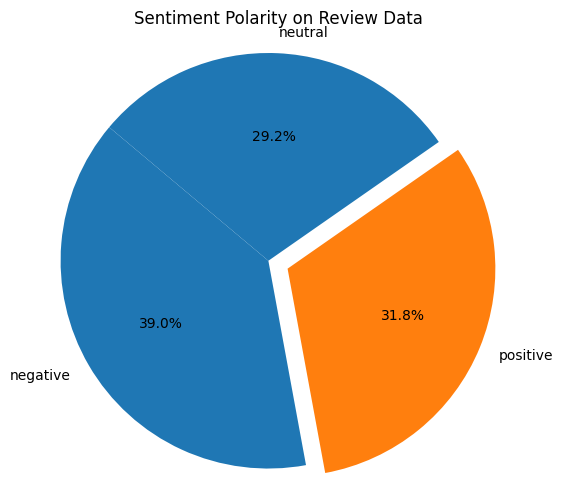

In [26]:
sentiment_counts = app_reviews_df['polarity'].value_counts()
labels = sentiment_counts.index.tolist()
sizes = sentiment_counts.values
colors = ['#1f77b4', '#ff7f0e']
explode = [0.1 if label == 'positive' else 0 for label in labels]


plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%.1f%%', startangle=140, explode=explode)
plt.axis('equal')  # Membuat lingkaran sempurna
plt.title("Sentiment Polarity on Review Data")
plt.show()


####  Sentimen Umum

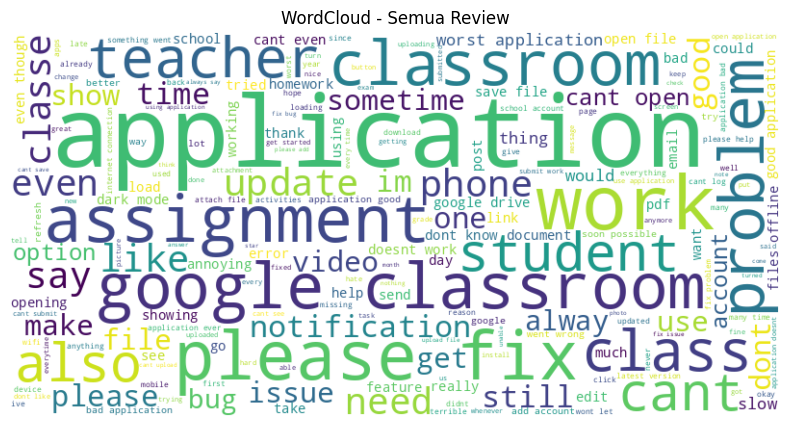

In [ ]:
all_words = ' '.join(app_reviews_df['text_akhir'].astype(str))
combined_stopwords = set(stopwords.words('indonesian') + stopwords.words('english'))
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=combined_stopwords).generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - Semua Review')
plt.show()

#### Sentimen Positif

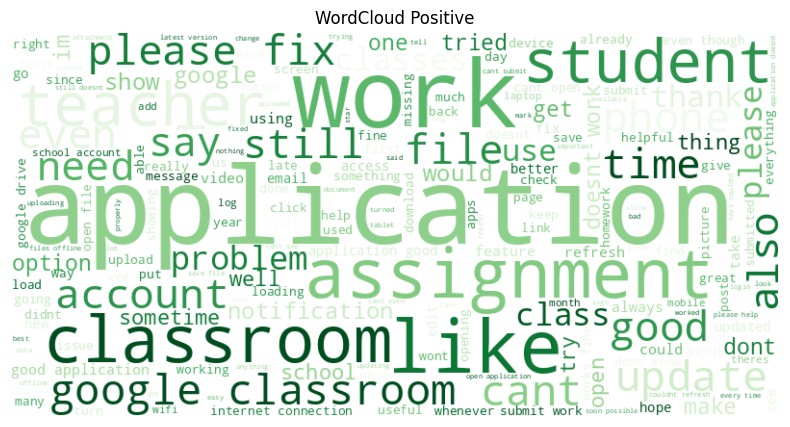

In [27]:
positive_words = ' '.join(app_reviews_df[app_reviews_df['polarity'] =='positive']['text_akhir'].astype(str))
combined_stopwords = set(stopwords.words('indonesian') + stopwords.words('english'))
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=combined_stopwords, colormap='Greens').generate(positive_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Positive')
plt.show()

#### Sentimen Negatif

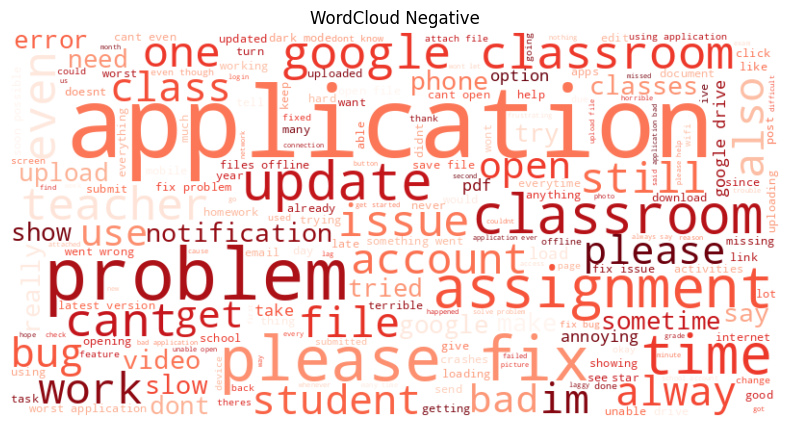

In [28]:
negative_words = ' '.join(app_reviews_df[app_reviews_df['polarity'] =='negative']['text_akhir'].astype(str))
combined_stopwords = set(stopwords.words('indonesian') + stopwords.words('english'))
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=combined_stopwords, colormap='Reds').generate(negative_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Negative')
plt.show()

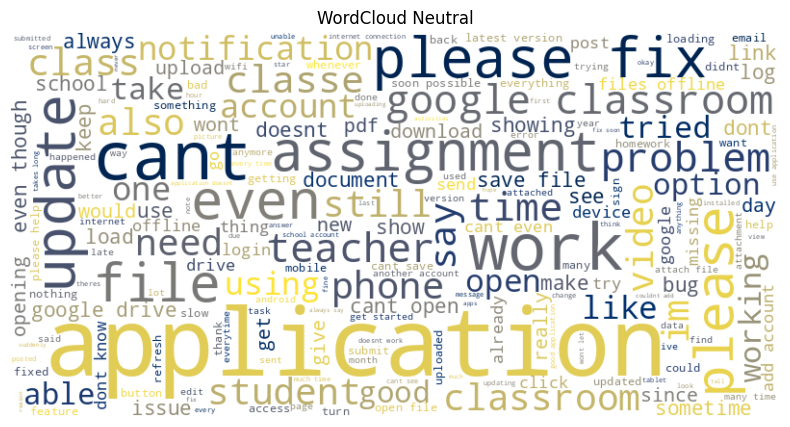

In [31]:
neutral_words = ' '.join(app_reviews_df[app_reviews_df['polarity'] =='neutral']['text_akhir'].astype(str))
combined_stopwords = set(stopwords.words('indonesian') + stopwords.words('english'))
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=combined_stopwords, colormap='cividis').generate(neutral_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Neutral')
plt.show()

### **Modelling dan Evaluation**

In [34]:
# 1. Persiapkan data
X = app_reviews_df['text_akhir']
y = app_reviews_df['polarity']

# 2. Ekstraksi fitur dengan TF-IDF
tfidf = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.9)
X_tfidf = tfidf.fit_transform(X)

# 2B. Ekstraksi fitur dengan CountVectorizer (BoW)
count_vect = CountVectorizer(
    max_features=5000,
    min_df=3,
    max_df=0.5,
    ngram_range=(1, 2)
)
X_bow = count_vect.fit_transform(X)

# 3. Tentukan rasio test/train
test_size = 0.20

# 4. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=test_size, random_state=42
)

# 4B. Split untuk BoW juga (pakai label yang sama)
X_train_bow, X_test_bow, _, _ = train_test_split(
    X_bow, y, test_size=test_size, random_state=42
)

# 5. Terapkan SMOTE pada data pelatihan TF-IDF
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 5B. SMOTE pada BoW juga jika ingin
X_train_bow_smote, y_train_bow_smote = smote.fit_resample(X_train_bow, y_train)

In [35]:
# Model 1 Linear SVC dengan TFIDF (75/25)
model_svc = LinearSVC(C=40, max_iter=10000, random_state=42)
model_svc.fit(X_train, y_train)
y_pred = model_svc.predict(X_test.toarray())

accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi: {round(accuracy, 3)}")
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive']))

Akurasi: 0.756

Laporan Klasifikasi:
              precision    recall  f1-score   support

    Negative       0.83      0.84      0.84       431
     Neutral       0.61      0.56      0.58       311
    Positive       0.78      0.82      0.80       369

    accuracy                           0.76      1111
   macro avg       0.74      0.74      0.74      1111
weighted avg       0.75      0.76      0.75      1111



In [36]:
# Model 2 Linear SVC dengan BoW (85/15)
model_bow_svc = LinearSVC(C=40, max_iter=10000, random_state=42)
model_bow_svc.fit(X_train_bow_smote.toarray(), y_train_bow_smote)
y_pred_bow = model_bow_svc.predict(X_test_bow.toarray())

accuracy = accuracy_score(y_test, y_pred_bow)
print(f"Akurasi: {round(accuracy, 3)}")
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred_bow, target_names=['Negative', 'Neutral', 'Positive']))

Akurasi: 0.629

Laporan Klasifikasi:
              precision    recall  f1-score   support

    Negative       0.75      0.70      0.72       431
     Neutral       0.42      0.41      0.41       311
    Positive       0.67      0.73      0.70       369

    accuracy                           0.63      1111
   macro avg       0.61      0.61      0.61      1111
weighted avg       0.63      0.63      0.63      1111



In [37]:
# Model 3 Random Forest dengan TFIDF (80/20)
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(n_estimators=500,
                               max_depth=None,
                               min_samples_split=2,
                               min_samples_leaf=1,
                               max_features='sqrt',
                               random_state=42)
model_rf.fit(X_train.toarray(), y_train)

y_pred = model_rf.predict(X_test.toarray())

accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi: {round(accuracy, 4)}")
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive']))

Akurasi: 0.7138

Laporan Klasifikasi:
              precision    recall  f1-score   support

    Negative       0.75      0.79      0.77       431
     Neutral       0.64      0.46      0.53       311
    Positive       0.72      0.84      0.78       369

    accuracy                           0.71      1111
   macro avg       0.70      0.70      0.69      1111
weighted avg       0.71      0.71      0.70      1111



### **Prediksi**

In [39]:
def predict_sentiment(text_baru, model, vectorizer):
    # 1. Preprocessing sama seperti data training
    text_baru = clean_text(text_baru)
    text_baru = casefoldingText(text_baru)
    text_baru = fix_slangwords(text_baru)
    text_baru = tokenizingText(text_baru)
    text_baru = filteringText(text_baru)
    text_baru = toSentence(text_baru)

    # 2. Transformasi teks ke bentuk vektor (TF-IDF)
    text_vector = vectorizer.transform([text_baru])

    # 3. Prediksi menggunakan model
    prediction = model.predict(text_vector.toarray())

    return prediction[0]


In [40]:
# Prediksi untuk Model Linear SVC dengan TFIDF (75/25)
teks_uji = "Google Classroom is really helpful and makes online learning easier!"
hasil_prediksi = predict_sentiment(teks_uji, model_svc, tfidf)
print("Sentimen:", hasil_prediksi)


Sentimen: positive


In [41]:
# Prediksi untuk Model Linear SVC dengan BoW (85/15)
teks_uji = "This app is terrible. It keeps crashing and I can't submit my assignments."
hasil_prediksi = predict_sentiment(teks_uji, model_bow_svc, count_vect)
print("Sentimen:", hasil_prediksi)

Sentimen: neutral


In [42]:
# Prediksi untuk Model Linear Random Forest dengan TFIDF (80/20)
teks_uji = "I used Google Classroom for school purposes. It works like most online tools."
hasil_prediksi = predict_sentiment(teks_uji, model_rf, tfidf)
print("Sentimen:", hasil_prediksi)

Sentimen: positive
